In [ ]:
# LIBRERÍAS

import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [ ]:
# CARGAR DATOS

digits = load_digits()

X = digits.data
y = digits.target

imagenes = digits.images

print("Número de imágenes:", len(imagenes))
print("Dimensiones de cada imagen:", imagenes[0].shape)
print("Número de clases:", len(np.unique(y)))

Número de imágenes: 1797
Dimensiones de cada imagen: (8, 8)
Número de clases: 10


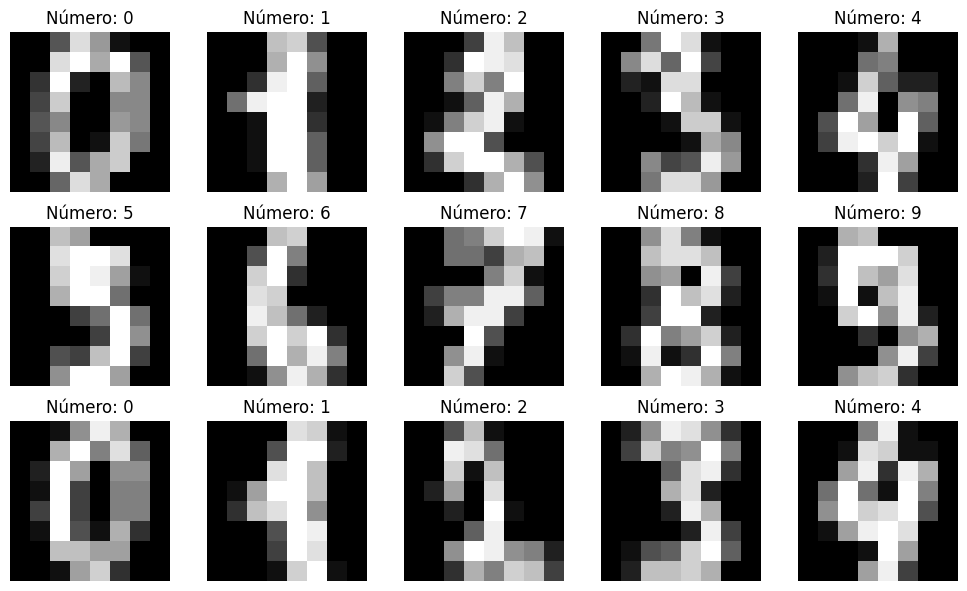

In [ ]:
# VISUALIZAR EJEMPLOS

plt.figure(figsize=(10, 6))

for i in range(15):

    plt.subplot(3, 5, i + 1)

    plt.imshow(
        imagenes[i],
        cmap="gray"
    )

    plt.title(
        f"Número: {y[i]}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [10]:
# NORMALIZACIÓN

X = X / 16.0

print("Mínimo:", X.min())
print("Máximo:", X.max())

Mínimo: 0.0
Máximo: 1.0


In [11]:
# TRAIN / TEST

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Entrenamiento:", X_train.shape)
print("Prueba:", X_test.shape)

Entrenamiento: (1437, 64)
Prueba: (360, 64)


In [12]:
# RED NEURONAL

modelo = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation="relu",
    solver="adam",
    learning_rate_init=0.001,
    max_iter=300,
    random_state=42
)

In [15]:
# ENTRENAR

modelo.fit(
    X_train,
    y_train
)

print("Entrenamiento terminado")

Entrenamiento terminado


In [16]:
# PREDICCIONES

predicciones = modelo.predict(
    X_test
)

accuracy = accuracy_score(
    y_test,
    predicciones
)

print(
    "Accuracy:",
    round(accuracy * 100, 2),
    "%"
)

Accuracy: 98.06 %


In [17]:
# MÉTRICAS

print(
    classification_report(
        y_test,
        predicciones,
        digits=4
    )
)

              precision    recall  f1-score   support

           0     1.0000    0.9722    0.9859        36
           1     0.9211    0.9722    0.9459        36
           2     1.0000    1.0000    1.0000        35
           3     1.0000    1.0000    1.0000        37
           4     0.9730    1.0000    0.9863        36
           5     1.0000    1.0000    1.0000        37
           6     1.0000    0.9722    0.9859        36
           7     0.9730    1.0000    0.9863        36
           8     0.9412    0.9143    0.9275        35
           9     1.0000    0.9722    0.9859        36

    accuracy                         0.9806       360
   macro avg     0.9808    0.9803    0.9804       360
weighted avg     0.9810    0.9806    0.9806       360



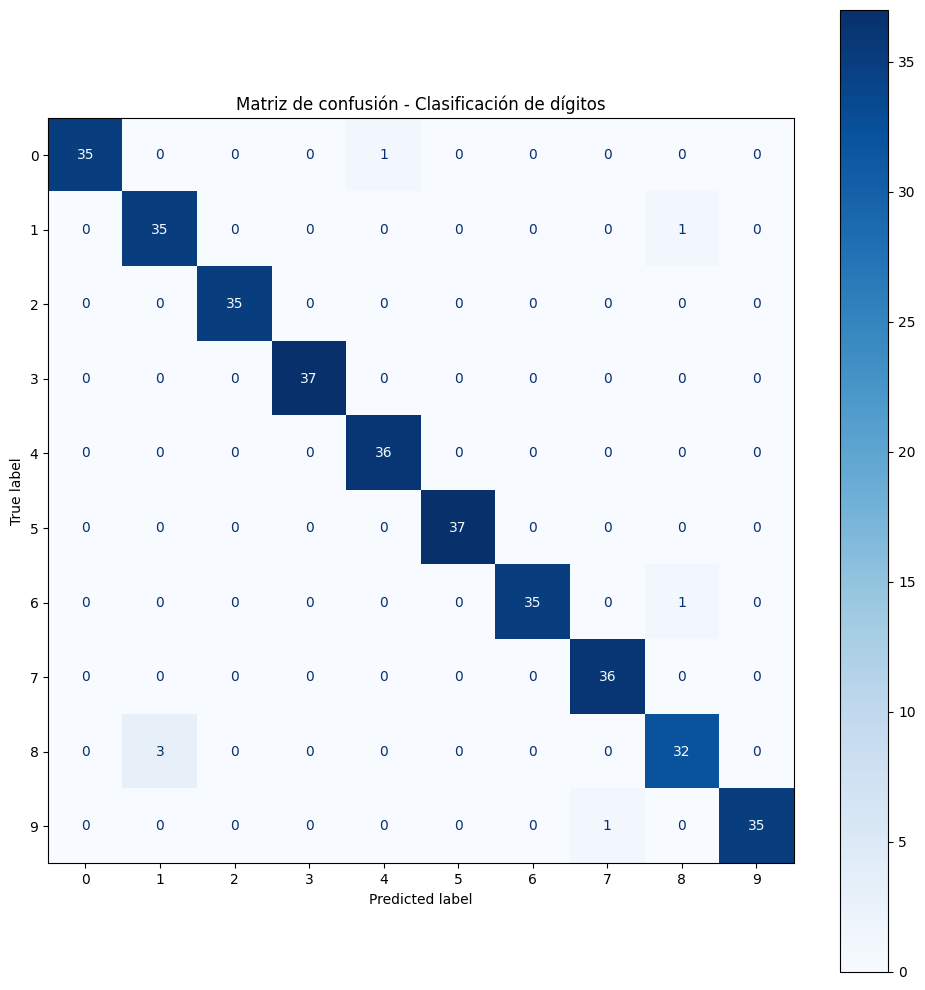

In [18]:
# MATRIZ DE CONFUSIÓN

matriz = confusion_matrix(
    y_test,
    predicciones
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=matriz,
    display_labels=range(10)
)

fig, ax = plt.subplots(
    figsize=(10, 10)
)

disp.plot(
    ax=ax,
    cmap="Blues"
)

plt.title(
    "Matriz de confusión - Clasificación de dígitos"
)

plt.tight_layout()
plt.show()

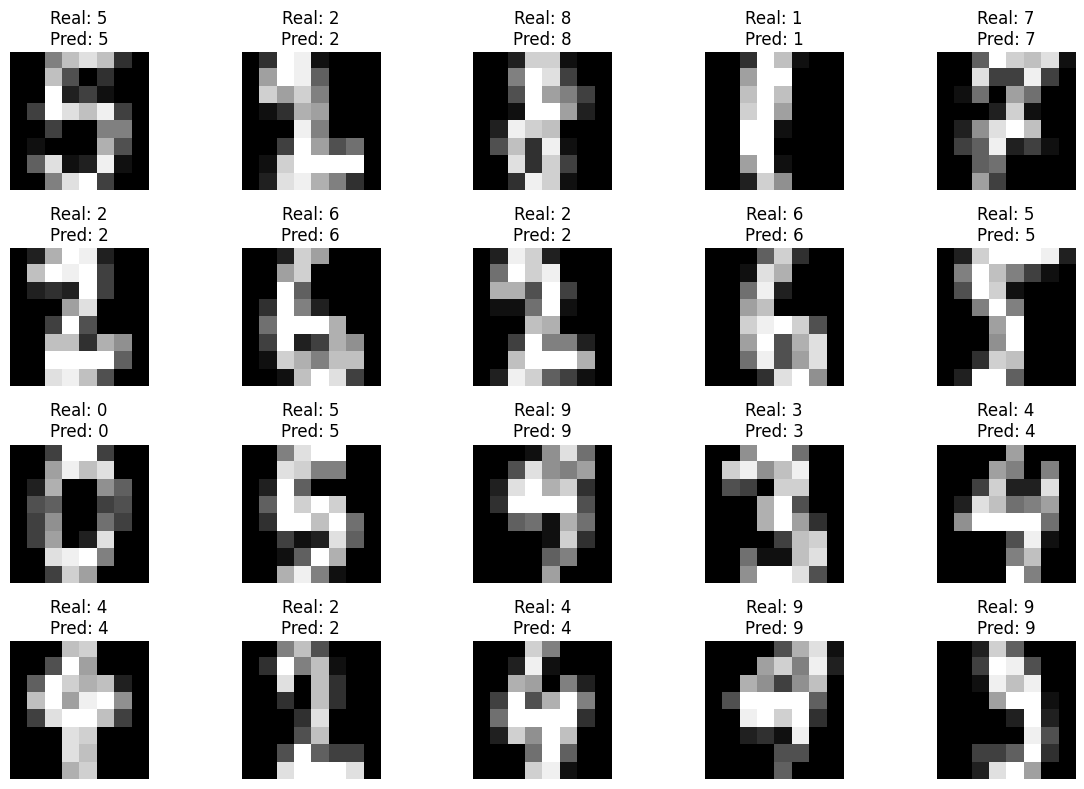

In [19]:
# VISUALIZAR PREDICCIONES

indices_test = y_test.index if hasattr(y_test, "index") else None

plt.figure(figsize=(12, 8))

for i in range(20):

    imagen = X_test[i].reshape(8, 8)

    plt.subplot(4, 5, i + 1)

    plt.imshow(
        imagen,
        cmap="gray"
    )

    plt.title(
        f"Real: {y_test[i]}\n"
        f"Pred: {predicciones[i]}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

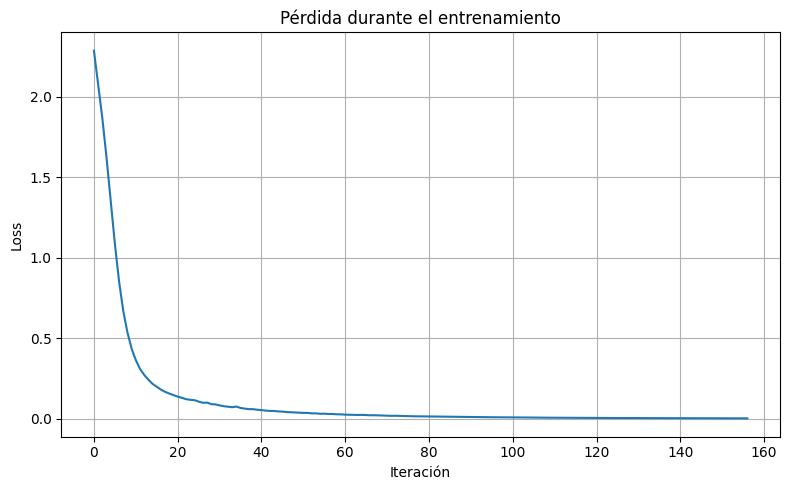

In [20]:
# CURVA DE PÉRDIDA

plt.figure(figsize=(8, 5))

plt.plot(
    modelo.loss_curve_
)

plt.title(
    "Pérdida durante el entrenamiento"
)

plt.xlabel(
    "Iteración"
)

plt.ylabel(
    "Loss"
)

plt.grid()

plt.tight_layout()
plt.show()